# Prophet SO2 Forecasting Model
## COS40007 Design Project - Smart Government
### Topic: Modeling Industrial Air Quality - Forecasting SO2 Emissions using IPI and Electricity Data

| Item | Detail |
|---|---|
| Model | Prophet (Facebook / Meta Forecasting Framework) |
| Target Variable (Y) | air_so2 - Sulfur Dioxide level |
| Predictor Variables (X) | ipi_growth_yoy_index_sa, electricity_local (as regressors) |
| Data | Monthly, Jan 2018 to Dec 2022 (60 rows) |
| Evaluation Metrics | RMSE, MAE, R-squared |

Folder structure:
```
ASSIGNMENT/
    data/
        combined_air_electricity_ipi_cleaned.csv
        Prophet.ipynb
```

## Section 1 - Library Imports

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

print('All libraries loaded successfully.')
print('If prophet is not installed, run: pip install prophet')

All libraries loaded successfully.
If prophet is not installed, run: pip install prophet


## Section 2 - Configuration

This is the only cell that needs to be edited if the filename or column names change. The notebook builds the file path relative to its own location, so it works as long as both the notebook and the CSV are inside the data folder.

In [25]:
# File path - the CSV is stored in COS40007DataCleaning
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
FILE_NAME    = 'combined_air_electricity_ipi_cleaned.csv'
FILE_PATH    = os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', FILE_NAME)

# Column names
COL_DATE   = 'date'
COL_TARGET = 'air_so2'                 # Y  - Sulfur Dioxide (target to forecast)
COL_IPI    = 'ipi_growth_yoy_index_sa' # X1 - IPI year-on-year growth (seasonally adjusted)
COL_ELEC   = 'electricity_local'       # X2 - Local electricity consumption

# Train/test split
TRAIN_RATIO = 0.80  # 80% train, 20% test

# Verify file exists before continuing
if os.path.exists(FILE_PATH):
    print('CSV found:', FILE_PATH)
else:
    print('ERROR: CSV not found at:', FILE_PATH)
    print('Make sure combined_air_electricity_ipi_cleaned.csv is in COS40007DataCleaning.')

CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\Prophet\..\COS40007DataCleaning\combined_air_electricity_ipi_cleaned.csv


## Section 3 - Load Dataset

In [26]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)

# Keep only the three columns used in this model
df = df_raw[[COL_DATE, COL_TARGET, COL_IPI, COL_ELEC]].copy()

print('Dataset loaded successfully.')
print('  Rows      :', len(df))
print('  Period    :', df[COL_DATE].min().strftime('%b %Y'), 'to', df[COL_DATE].max().strftime('%b %Y'))
print('  Columns   :', df.columns.tolist())
print('  Nulls     :', df.isnull().sum().sum(), '(should be 0)')
print()
df.head()

Dataset loaded successfully.
  Rows      : 60
  Period    : Jan 2018 to Dec 2022
  Columns   : ['date', 'air_so2', 'ipi_growth_yoy_index_sa', 'electricity_local']
  Nulls     : 0 (should be 0)



,date,air_so2,ipi_growth_yoy_index_sa,electricity_local
0,2018-01-01,0.0010,3.963,11845.900250
1,2018-02-01,0.0011,2.625,11091.957006
2,2018-03-01,0.0010,3.328,12244.089947
3,2018-04-01,0.0010,5.918,12018.584577
4,2018-05-01,0.0010,4.320,12267.998390


## Section 4 - Descriptive Statistics and Exploratory Overview

In [27]:
print('=== Descriptive Statistics ===')
print(df[[COL_TARGET, COL_IPI, COL_ELEC]].describe().round(6))

=== Descriptive Statistics ===
         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


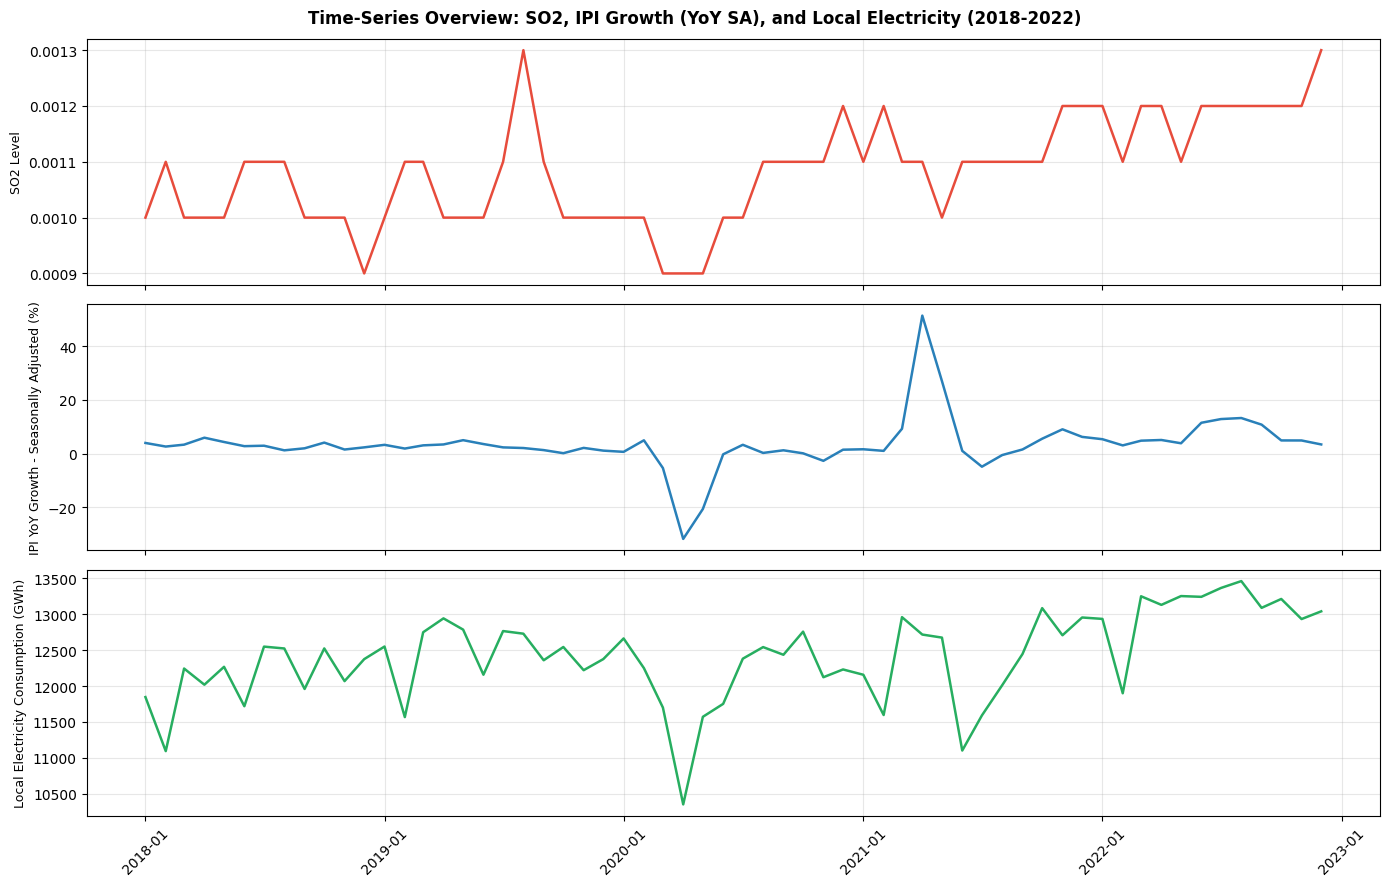

Saved: 01_time_series_overview.png


In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Time-Series Overview: SO2, IPI Growth (YoY SA), and Local Electricity (2018-2022)',
             fontsize=12, fontweight='bold')

plot_cfg = [
    (COL_TARGET, '#e74c3c', 'SO2 Level'),
    (COL_IPI,    '#2980b9', 'IPI YoY Growth - Seasonally Adjusted (%)'),
    (COL_ELEC,   '#27ae60', 'Local Electricity Consumption (GWh)'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df[COL_DATE], df[col], color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_time_series_overview.png')

## Section 5 - Prepare Data for Prophet

Prophet requires the date column to be named ds and the target column to be named y. Additional predictor variables are added as extra regressors. MinMaxScaler is applied to the regressor columns to bring IPI and electricity onto a comparable scale before passing them into the model. The scaler is fitted on the training set only.

In [29]:
# Rename columns to Prophet required format
prophet_df = df.rename(columns={
    COL_DATE   : 'ds',
    COL_TARGET : 'y',
    COL_IPI    : 'ipi_growth',
    COL_ELEC   : 'elec_local'
})

# Train/test split (chronological)
split_idx   = int(len(prophet_df) * TRAIN_RATIO)
train_df    = prophet_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df     = prophet_df.iloc[split_idx:].copy().reset_index(drop=True)

print('Train/test split complete (chronological, no shuffle).')
print('  Train :', len(train_df), 'months  (',
      train_df['ds'].min().strftime('%b %Y'), 'to', train_df['ds'].max().strftime('%b %Y'), ')')
print('  Test  :', len(test_df),  'months   (',
      test_df['ds'].min().strftime('%b %Y'),  'to', test_df['ds'].max().strftime('%b %Y'),  ')')

Train/test split complete (chronological, no shuffle).
  Train : 48 months  ( Jan 2018 to Dec 2021 )
  Test  : 12 months   ( Jan 2022 to Dec 2022 )


In [30]:
# Scale the regressor columns using MinMaxScaler
# Scaler fitted on train set only to prevent data leakage
scaler_reg = MinMaxScaler()

train_df[['ipi_growth', 'elec_local']] = scaler_reg.fit_transform(
    train_df[['ipi_growth', 'elec_local']]
)
test_df[['ipi_growth', 'elec_local']] = scaler_reg.transform(
    test_df[['ipi_growth', 'elec_local']]
)

print('Regressor scaling complete. Scaler fitted on training set only.')
print('  ipi_growth range after scaling  -  train: [{:.4f}, {:.4f}]'.format(
    train_df['ipi_growth'].min(), train_df['ipi_growth'].max()))
print('  elec_local range after scaling  -  train: [{:.4f}, {:.4f}]'.format(
    train_df['elec_local'].min(), train_df['elec_local'].max()))

Regressor scaling complete. Scaler fitted on training set only.
  ipi_growth range after scaling  -  train: [0.0000, 1.0000]
  elec_local range after scaling  -  train: [0.0000, 1.0000]


## Section 6 - Build and Train Prophet Model

Prophet decomposes the time series into trend, seasonality, and regressor components. Monthly data with 60 observations does not support weekly seasonality, so only yearly seasonality is enabled. The two scaled regressors, ipi_growth and elec_local, are added as additional predictors. The model is fitted on the training set only.

In [31]:
model = Prophet(
    yearly_seasonality  = True,   # Monthly data can capture yearly patterns
    weekly_seasonality  = False,  # Not applicable for monthly data
    daily_seasonality   = False,  # Not applicable for monthly data
    seasonality_mode    = 'additive',  # SO2 fluctuations are not multiplicative
    interval_width      = 0.95    # 95% uncertainty interval in plots
)

# Add external regressors
model.add_regressor('ipi_growth')
model.add_regressor('elec_local')

# Fit on training data
model.fit(train_df)

print('Prophet model trained successfully.')

12:13:58 - cmdstanpy - INFO - Chain [1] start processing
12:13:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


## Section 7 - Generate Predictions

Prophet requires a future dataframe with ds, and any extra regressor columns, to generate predictions. The test regressor values (scaled) are passed in for the test period. Predictions for the training period are obtained separately using the same training dataframe.

In [32]:
# Predict on training set
train_forecast = model.predict(train_df[['ds', 'ipi_growth', 'elec_local']])

# Predict on test set
test_forecast  = model.predict(test_df[['ds', 'ipi_growth', 'elec_local']])

# Extract yhat (point forecast), yhat_lower and yhat_upper (uncertainty bounds)
y_pred_train = train_forecast['yhat'].values
y_pred_test  = test_forecast['yhat'].values
y_lower_test = test_forecast['yhat_lower'].values
y_upper_test = test_forecast['yhat_upper'].values

y_actual_train = train_df['y'].values
y_actual_test  = test_df['y'].values

print('Predictions generated.')
print('  Training predictions shape :', y_pred_train.shape)
print('  Test predictions shape     :', y_pred_test.shape)

Predictions generated.
  Training predictions shape : (48,)
  Test predictions shape     : (12,)


## Section 8 - Evaluation (RMSE, MAE, R-squared)

In [33]:
train_rmse = np.sqrt(mean_squared_error(y_actual_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_actual_test,  y_pred_test))
train_mae  = mean_absolute_error(y_actual_train, y_pred_train)
test_mae   = mean_absolute_error(y_actual_test,  y_pred_test)
train_r2   = r2_score(y_actual_train, y_pred_train)
test_r2    = r2_score(y_actual_test,  y_pred_test)

print('=' * 50)
print('EVALUATION METRICS')
print('=' * 50)
print('\nTRAINING SET METRICS:')
print(f'  RMSE : {train_rmse:.6f}')
print(f'  MAE  : {train_mae:.6f}')
print(f'  R2   : {train_r2:.4f}')
print('\nTEST SET METRICS:')
print(f'  RMSE : {test_rmse:.6f}')
print(f'  MAE  : {test_mae:.6f}')
print(f'  R2   : {test_r2:.4f}')
print('=' * 50)

if test_r2 < 0:
    print('\nNote: A negative R2 on the test set indicates the model performs worse than')
    print('a simple mean baseline. This is a known challenge when the target variable')
    print('has very low variance, as is the case with SO2 which ranges only from')
    print('0.0009 to 0.0013 across 60 months.')
elif test_r2 < 0.5:
    print('\nNote: R2 below 0.5 suggests moderate explanatory power.')
    print('Given the limited variability in SO2 values, this is an expected outcome.')
else:
    print('\nR2 above 0.5 indicates reasonable model fit on the test set.')

EVALUATION METRICS

TRAINING SET METRICS:
  RMSE : 0.000047
  MAE  : 0.000038
  R2   : 0.6830

TEST SET METRICS:
  RMSE : 0.000065
  MAE  : 0.000049
  R2   : -0.7249

Note: A negative R2 on the test set indicates the model performs worse than
a simple mean baseline. This is a known challenge when the target variable
has very low variance, as is the case with SO2 which ranges only from
0.0009 to 0.0013 across 60 months.


## Section 9 - Actual vs Predicted Visualization

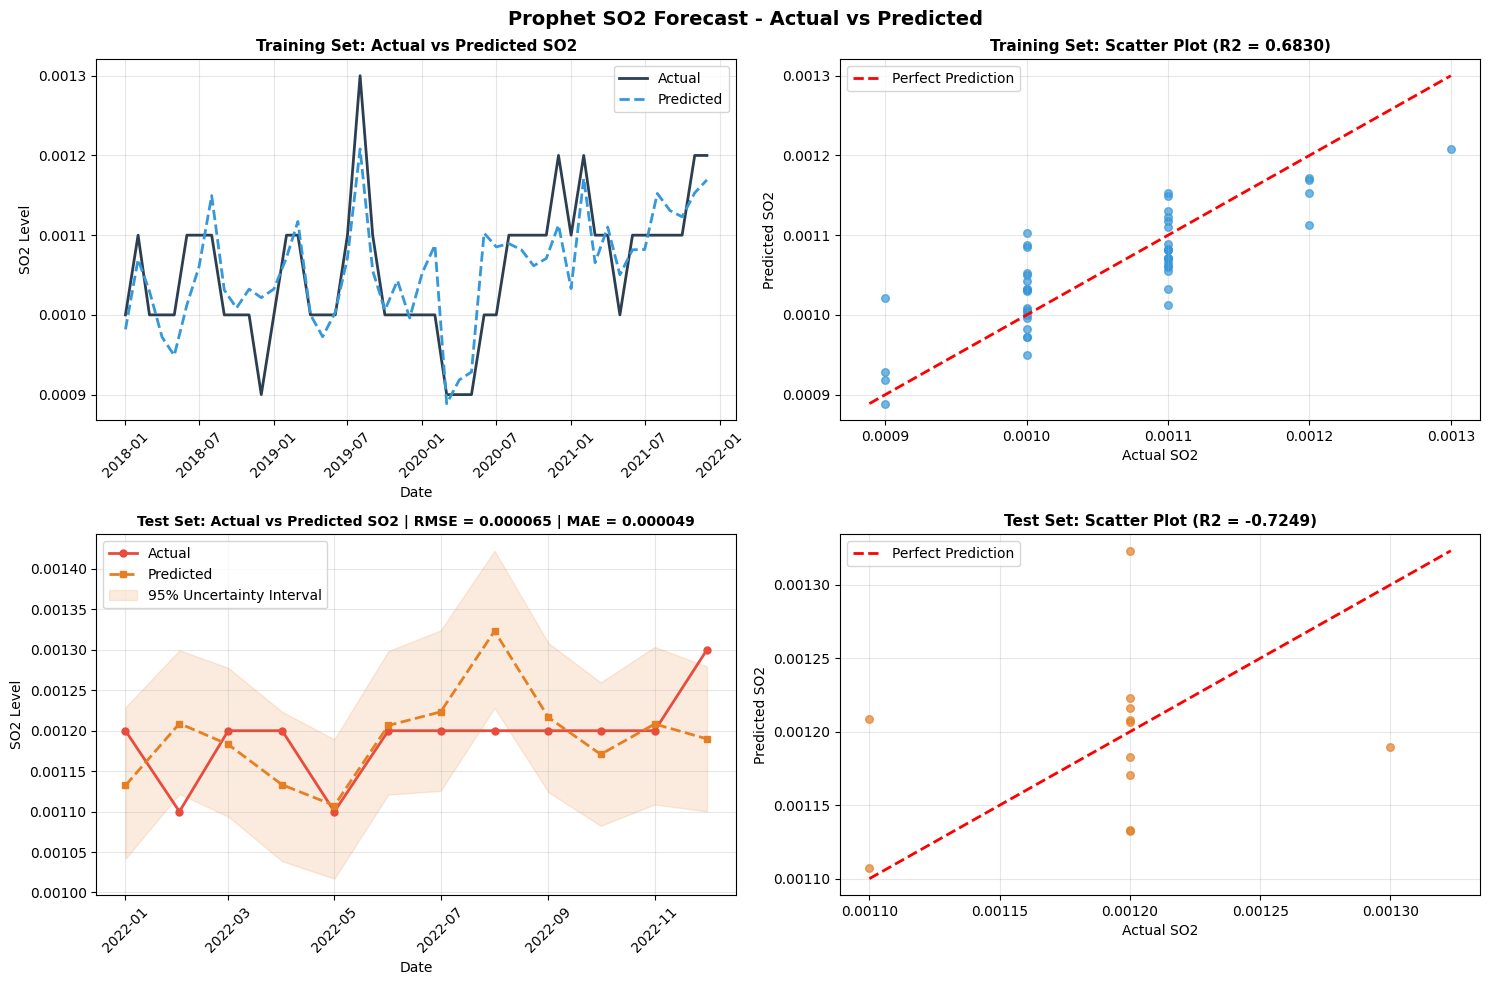

Saved: 02_actual_vs_predicted.png


In [34]:
train_dates = train_df['ds'].values
test_dates  = test_df['ds'].values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Prophet SO2 Forecast - Actual vs Predicted', fontsize=14, fontweight='bold')

# Training set - time series
axes[0, 0].plot(train_dates, y_actual_train, label='Actual', linewidth=2, color='#2c3e50')
axes[0, 0].plot(train_dates, y_pred_train,   label='Predicted', linewidth=2, color='#3498db', linestyle='--')
axes[0, 0].set_title('Training Set: Actual vs Predicted SO2', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('SO2 Level')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0, 0].get_xticklabels(), rotation=45)

# Training set - scatter
axes[0, 1].scatter(y_actual_train, y_pred_train, alpha=0.7, s=30, color='#3498db')
lim = [min(y_actual_train.min(), y_pred_train.min()), max(y_actual_train.max(), y_pred_train.max())]
axes[0, 1].plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Training Set: Scatter Plot (R2 = {train_r2:.4f})', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Actual SO2')
axes[0, 1].set_ylabel('Predicted SO2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test set - time series with uncertainty interval
axes[1, 0].plot(test_dates, y_actual_test, label='Actual', linewidth=2, color='#e74c3c', marker='o', ms=5)
axes[1, 0].plot(test_dates, y_pred_test,   label='Predicted', linewidth=2, color='#e67e22', linestyle='--', marker='s', ms=5)
axes[1, 0].fill_between(test_dates, y_lower_test, y_upper_test,
                         alpha=0.15, color='#e67e22', label='95% Uncertainty Interval')
axes[1, 0].set_title(f'Test Set: Actual vs Predicted SO2 | RMSE = {test_rmse:.6f} | MAE = {test_mae:.6f}',
                      fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('SO2 Level')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Test set - scatter
axes[1, 1].scatter(y_actual_test, y_pred_test, alpha=0.7, s=30, color='#e67e22')
lim2 = [min(y_actual_test.min(), y_pred_test.min()), max(y_actual_test.max(), y_pred_test.max())]
axes[1, 1].plot(lim2, lim2, 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_title(f'Test Set: Scatter Plot (R2 = {test_r2:.4f})', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Actual SO2')
axes[1, 1].set_ylabel('Predicted SO2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_actual_vs_predicted.png')

## Section 10 - Residual Analysis

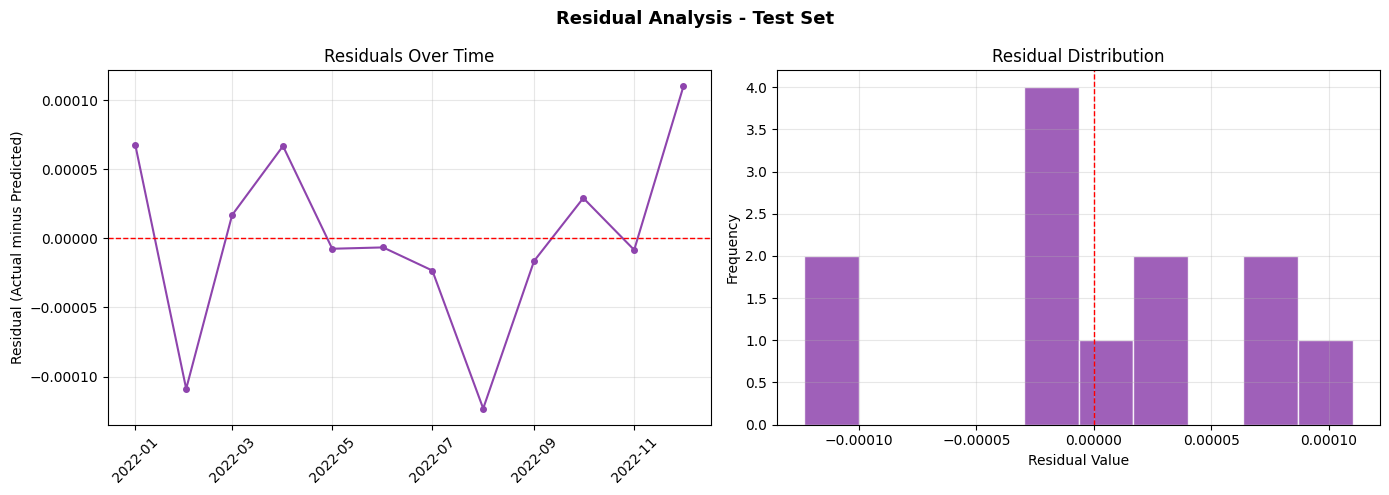

Saved: 03_residual_analysis.png
  Residual mean : -0.0 (ideally close to 0)
  Residual std  : 6.5e-05


In [35]:
residuals = y_actual_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis - Test Set', fontsize=13, fontweight='bold')

axes[0].plot(test_dates, residuals, color='#8e44ad', lw=1.5, marker='o', ms=4)
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual (Actual minus Predicted)')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].get_xticklabels(), rotation=45)

axes[1].hist(residuals, bins=10, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_residual_analysis.png')
print('  Residual mean :', round(residuals.mean(), 6), '(ideally close to 0)')
print('  Residual std  :', round(residuals.std(), 6))

## Section 11 - Prophet Component Decomposition

Prophet decomposes the forecast into interpretable components: trend, yearly seasonality, and the contribution of each external regressor. This plot is unique to Prophet and provides insight into how each component contributes to the overall SO2 forecast.

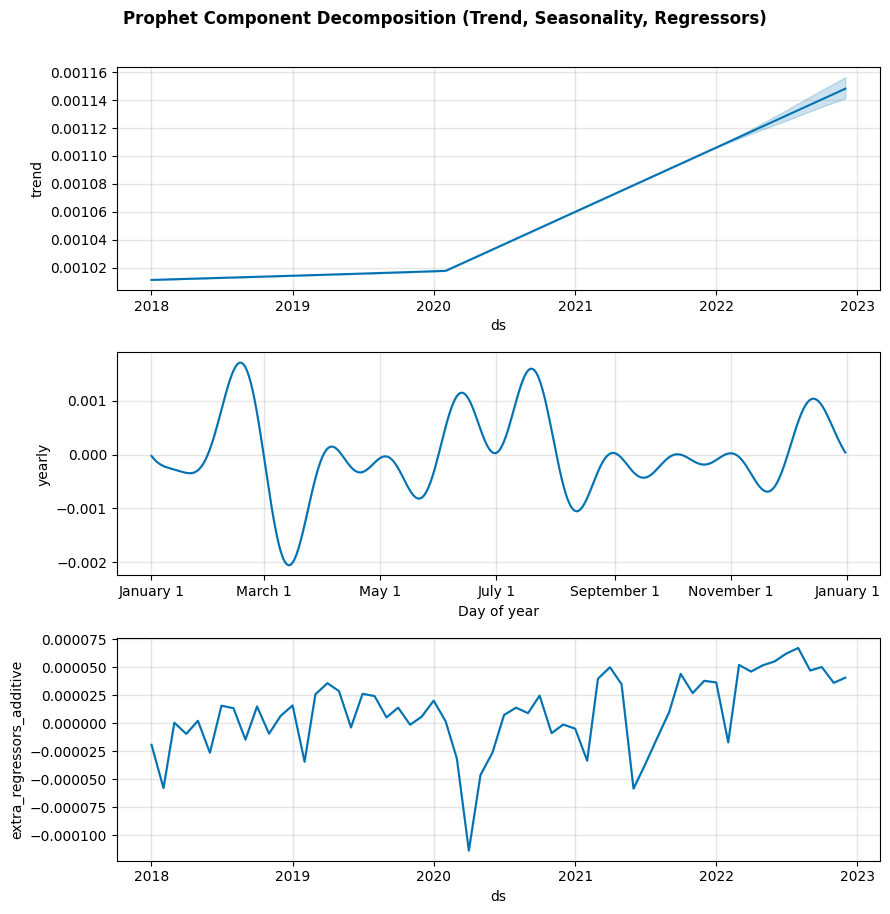

Saved: 04_prophet_components.png


In [36]:
# Build a combined dataframe for component plotting (train + test)
full_df  = prophet_df.copy()
full_df  = full_df.rename(columns={
    COL_DATE   : 'ds',
    COL_TARGET : 'y',
    COL_IPI    : 'ipi_growth',
    COL_ELEC   : 'elec_local'
})

# Scale regressors using the already-fitted scaler
full_df[['ipi_growth', 'elec_local']] = scaler_reg.transform(
    full_df[['ipi_growth', 'elec_local']]
)

full_forecast = model.predict(full_df[['ds', 'ipi_growth', 'elec_local']])

fig = model.plot_components(full_forecast)
fig.suptitle('Prophet Component Decomposition (Trend, Seasonality, Regressors)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_prophet_components.png')

## Section 12 - Full Forecast Plot with Uncertainty Interval

This is Prophet's native forecast plot showing the full training and test period together with the 95% uncertainty interval. The shaded region represents the model's confidence bounds around the point forecast.

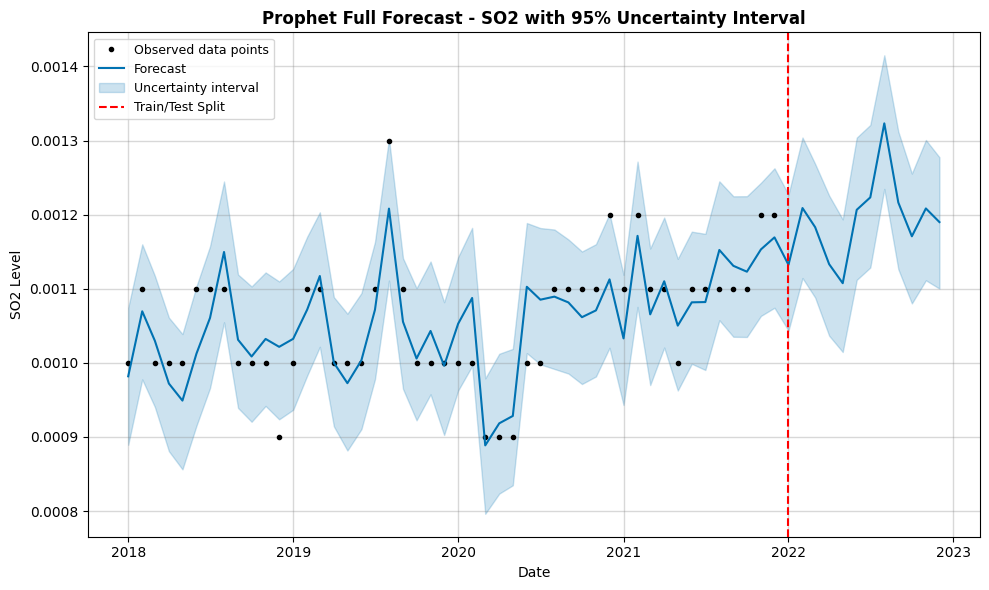

Saved: 05_prophet_full_forecast.png


In [37]:
fig = model.plot(full_forecast)
ax  = fig.gca()

# Mark the train/test boundary
split_date = test_df['ds'].iloc[0]
ax.axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.legend(fontsize=9)
ax.set_title('Prophet Full Forecast - SO2 with 95% Uncertainty Interval', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('SO2 Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_prophet_full_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_prophet_full_forecast.png')

## Section 13 - Save Results Summary

In [38]:
summary = pd.DataFrame({
    'Model'      : ['Prophet'],
    'Train RMSE' : [round(train_rmse, 6)],
    'Test RMSE'  : [round(test_rmse,  6)],
    'Train MAE'  : [round(train_mae,  6)],
    'Test MAE'   : [round(test_mae,   6)],
    'Train R2'   : [round(train_r2,   4)],
    'Test R2'    : [round(test_r2,    4)],
})

summary.to_csv('prophet_results_summary.csv', index=False)
print('Saved: prophet_results_summary.csv')
print()
print(summary.to_string(index=False))

Saved: prophet_results_summary.csv

  Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2
Prophet    0.000047   0.000065   0.000038  0.000049     0.683  -0.7249


---
## Section 14 - Methodology Notes (for Report)

### What is Prophet?

Prophet is an open-source forecasting framework developed by Meta (formerly Facebook). It is designed for time-series data with strong seasonal patterns and is particularly robust to missing data and trend shifts. Prophet decomposes the time series additively into three components: a piecewise linear or logistic trend, Fourier-series-based seasonality, and the effect of user-defined external regressors.

The general model form is:

    y(t) = trend(t) + seasonality(t) + regressors(t) + noise

### Why Prophet for This Project?

Prophet was selected as the second univariate-style forecasting model in this project because it provides an interpretable decomposition of the forecast into trend, seasonality, and regressor contributions. Unlike SARIMA, which requires manual identification of order parameters, Prophet is largely automated and handles monthly data with yearly seasonality directly. The component plots allow visual inspection of how IPI growth and electricity consumption each contribute to SO2 forecasts, which directly supports the research hypothesis.

### Regressor Configuration

Both ipi_growth_yoy_index_sa and electricity_local are added as additional regressors. These are the same predictor variables used in the XGBoost and LSTM models, ensuring a fair comparison. MinMaxScaler is applied to the regressor columns, fitted on the training set only, to bring them onto a comparable numerical scale before being passed into Prophet.

### Seasonality Configuration

Only yearly seasonality is enabled. Weekly and daily seasonality are disabled because the data is monthly and there are insufficient observations to fit those components reliably. The seasonality mode is set to additive because SO2 fluctuations are absolute changes rather than proportional ones.

### Uncertainty Intervals

Prophet generates 95% uncertainty intervals around each point forecast using a Bayesian approach (Monte Carlo sampling of posterior distributions). These intervals are shown in the forecast plots and represent the range within which the true SO2 value is expected to fall with 95% probability under the model assumptions.

### Train/Test Split Rationale

An 80/20 chronological split is used. The first 48 months form the training set and the final 12 months (all of 2022) form the test set. No shuffling is applied. Regressors are scaled using a scaler fitted only on the training set before the test set values are transformed.

### Evaluation Metrics

Three metrics are reported for both train and test sets. RMSE penalises large errors more heavily and is sensitive to months with unusual SO2 spikes. MAE reports the average error magnitude in the original SO2 units and is more robust to outliers. R-squared measures how much variance in SO2 is explained by the model; a value close to 1 indicates good fit, while a negative value indicates the model performs worse than simply predicting the mean.

### Note on SO2 Data Characteristics

The SO2 variable in this dataset has very low variance, with values ranging only from 0.0009 to 0.0013 across 60 months. Any model, including Prophet, will produce numerically small RMSE and MAE values that appear close to zero. However, the R-squared metric is a more reliable indicator of actual model fit as it accounts for the baseline variance of the target. A negative R-squared on the test set reflects this challenge and is expected given the limited range of the target variable.

### Limitations

Prophet is primarily designed for univariate forecasting and treats external regressors as linear additive effects. Non-linear interactions between IPI, electricity, and SO2 may not be captured as effectively as in XGBoost or LSTM. Prophet also requires the future values of regressors to be known at prediction time, which in a real deployment scenario would require separate forecasts for IPI and electricity. With only 60 months of data, the yearly seasonality component is estimated from just 5 full cycles, which limits its reliability.

---
## Section 15 - Interview Preparation

**Q: Why did you choose Prophet?**

Prophet was chosen because it provides an interpretable decomposition of the forecast into trend, seasonality, and regressor contributions. This makes it easy to explain which components are driving the SO2 forecast and to visually verify whether IPI and electricity are contributing meaningfully. It is also robust to missing data and does not require manual ARIMA order identification.

**Q: How does Prophet differ from SARIMA and XGBoost?**

SARIMA is a purely statistical model that captures autocorrelation patterns in the target variable itself but cannot easily include external predictors. XGBoost is a machine learning model that requires explicit feature engineering through lag variables to handle time series. Prophet sits between the two - it is designed specifically for time series, handles seasonality and trends automatically, and can incorporate external regressors as linear additive effects, but it assumes those regressor effects are linear.

**Q: What do the component decomposition plots tell you?**

The trend component shows the overall long-term direction of SO2 over the 2018 to 2022 period. The yearly seasonality component shows whether SO2 has a consistent pattern across months of the year. The regressor components show the contribution of IPI growth and electricity consumption to the forecast - if these components show meaningful variation, it supports the hypothesis that industrial activity influences SO2 levels.

**Q: How did you prevent data leakage in Prophet?**

The MinMaxScaler was fitted only on the training set before scaling the regressor columns. The test regressor values were then transformed using the same fitted scaler. The train/test split is strictly chronological with no shuffling, so no future information is available during model training.

**Q: What are the limitations of Prophet for this problem?**

Prophet assumes linear regressor effects, which may not capture complex non-linear relationships between IPI, electricity, and SO2. It requires the future values of regressors to be known at prediction time. The small dataset of 60 months means the yearly seasonality component is fitted from only 5 annual cycles, which limits reliability. The very low variance in SO2 values also makes it difficult for any model to achieve a high R-squared score.

---
*End of Prophet Notebook - COS40007 Design Project*